   rownames  year              species          species_latin  count  hours  \
0         1  1921     American Bittern  Botaurus lentiginosus      0    8.0   
1         2  1921  American Black Duck          Anas rubripes      0    8.0   
2         3  1921        American Coot       Fulica americana      0    8.0   
3         4  1921        American Crow  Corvus brachyrhynchos      0    8.0   
4         5  1921   American Goldfinch         Spinus tristis      0    8.0   

   count_per_hour  count_per_week species_binary  
0             0.0             0.0  American Crow  
1             0.0             0.0  American Crow  
2             0.0             0.0  American Coot  
3             0.0             0.0  American Crow  
4             0.0             0.0  American Crow  
Dataset Shape: (26800, 9)
rownames             0
year                 0
species              0
species_latin        0
count                0
hours             5405
count_per_hour    5405
count_per_week    5405
species_b

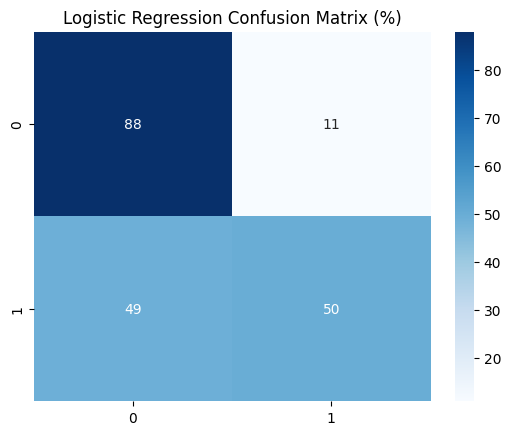


Decision Tree
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2975
         1.0       1.00      1.00      1.00      2385

    accuracy                           1.00      5360
   macro avg       1.00      1.00      1.00      5360
weighted avg       1.00      1.00      1.00      5360



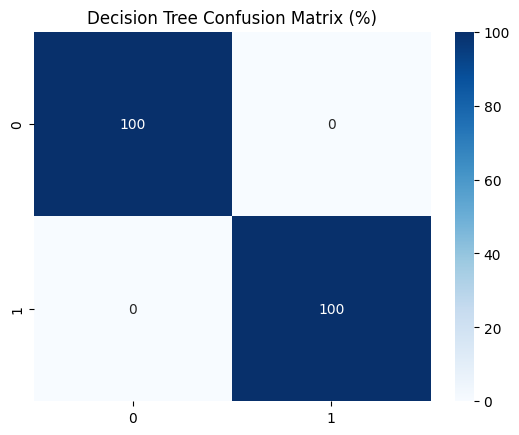


Random Forest
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2975
         1.0       1.00      1.00      1.00      2385

    accuracy                           1.00      5360
   macro avg       1.00      1.00      1.00      5360
weighted avg       1.00      1.00      1.00      5360



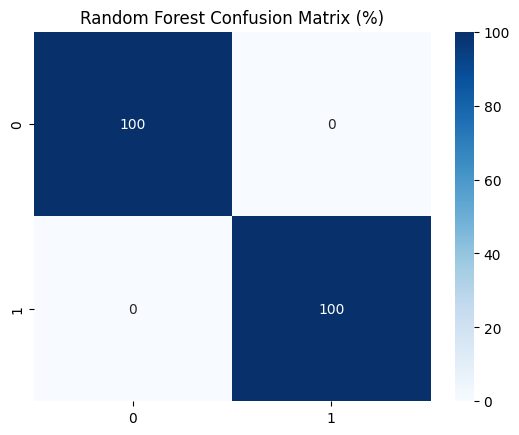


SVM
Accuracy: 0.7255597014925373
Precision: 0.9445525291828794
Recall: 0.4071278825995807
F1 Score: 0.5690008789920891

Classification Report
              precision    recall  f1-score   support

         0.0       0.67      0.98      0.80      2975
         1.0       0.94      0.41      0.57      2385

    accuracy                           0.73      5360
   macro avg       0.81      0.69      0.68      5360
weighted avg       0.79      0.73      0.70      5360



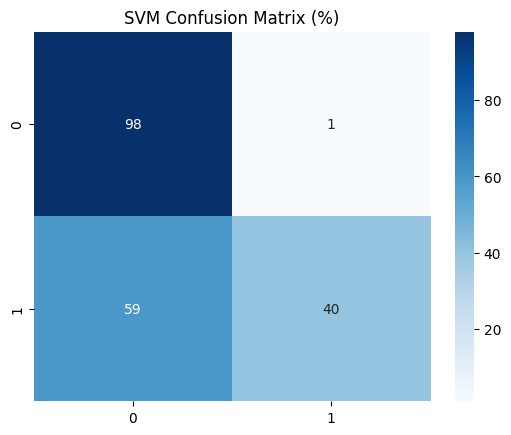


KNN
Accuracy: 0.9996268656716418
Precision: 1.0
Recall: 0.9991614255765199
F1 Score: 0.9995805369127517

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2975
         1.0       1.00      1.00      1.00      2385

    accuracy                           1.00      5360
   macro avg       1.00      1.00      1.00      5360
weighted avg       1.00      1.00      1.00      5360



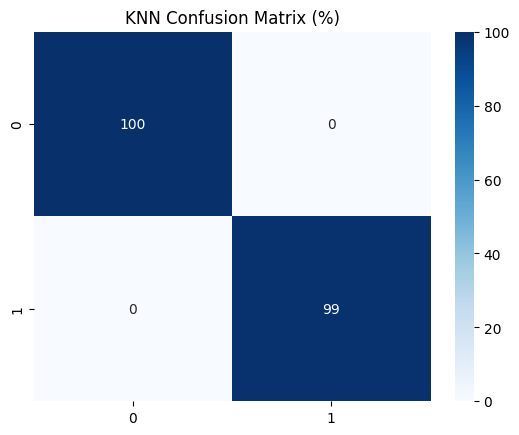


Naive Bayes
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2975
         1.0       1.00      1.00      1.00      2385

    accuracy                           1.00      5360
   macro avg       1.00      1.00      1.00      5360
weighted avg       1.00      1.00      1.00      5360



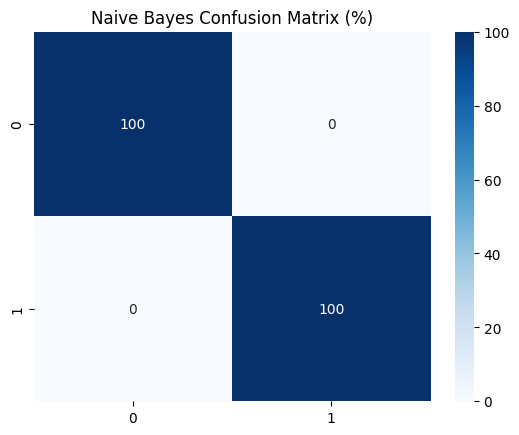


Gradient Boosting
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2975
         1.0       1.00      1.00      1.00      2385

    accuracy                           1.00      5360
   macro avg       1.00      1.00      1.00      5360
weighted avg       1.00      1.00      1.00      5360



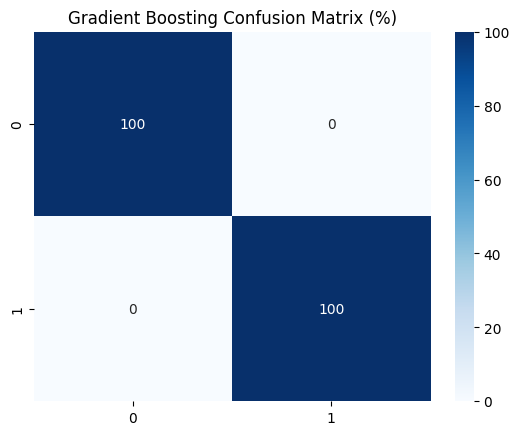


AdaBoost
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2975
         1.0       1.00      1.00      1.00      2385

    accuracy                           1.00      5360
   macro avg       1.00      1.00      1.00      5360
weighted avg       1.00      1.00      1.00      5360



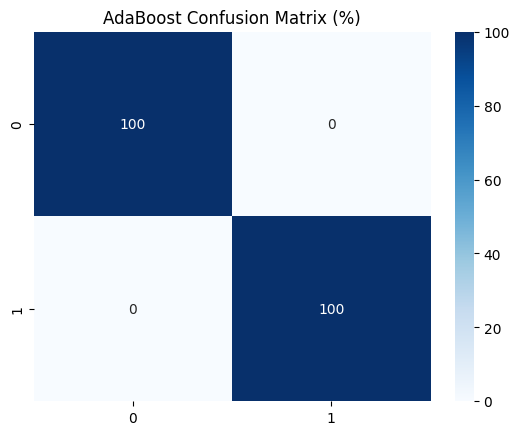


XGBoost
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2975
         1.0       1.00      1.00      1.00      2385

    accuracy                           1.00      5360
   macro avg       1.00      1.00      1.00      5360
weighted avg       1.00      1.00      1.00      5360



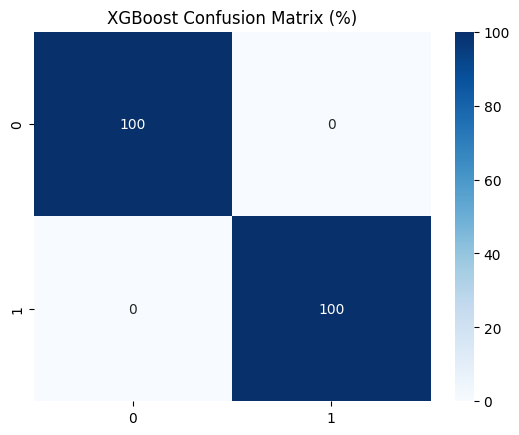

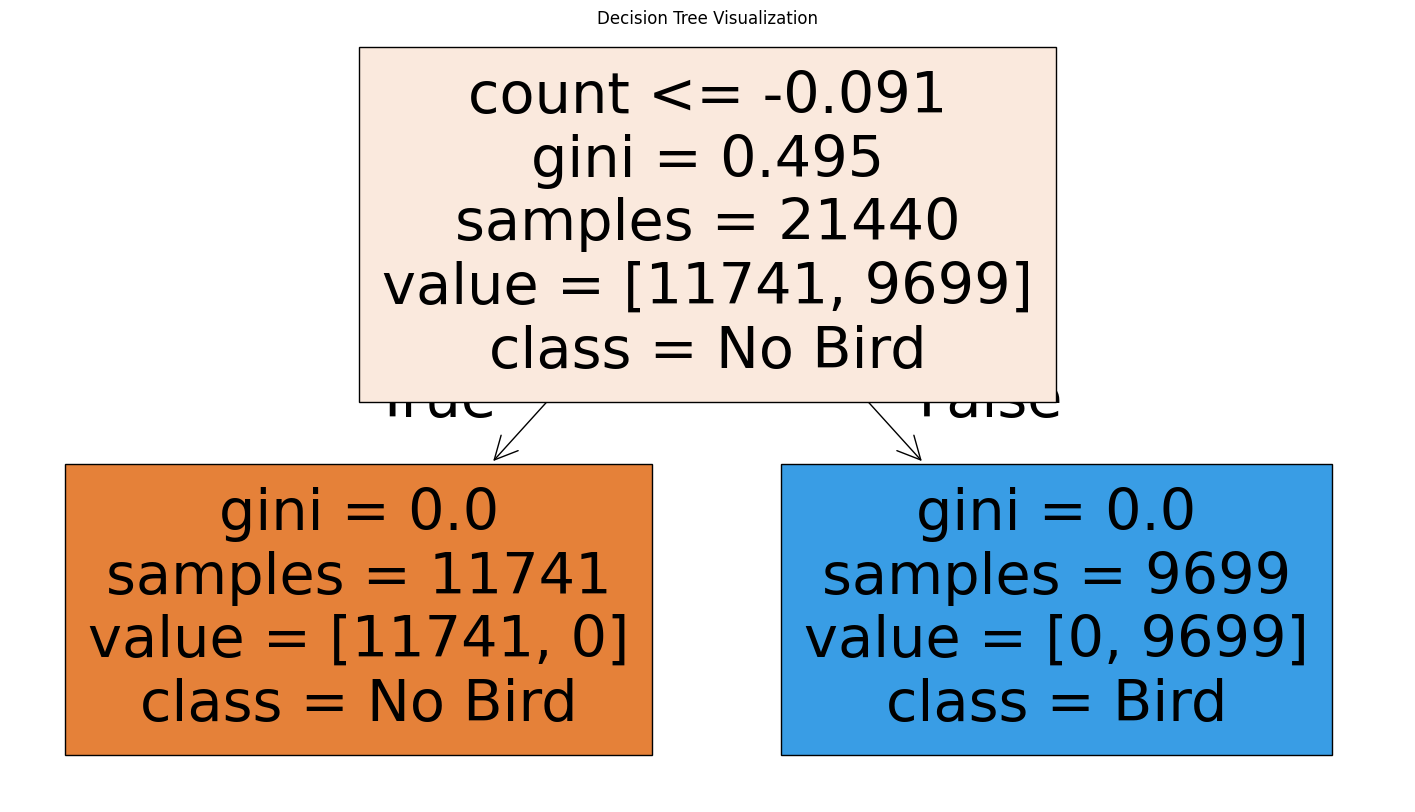

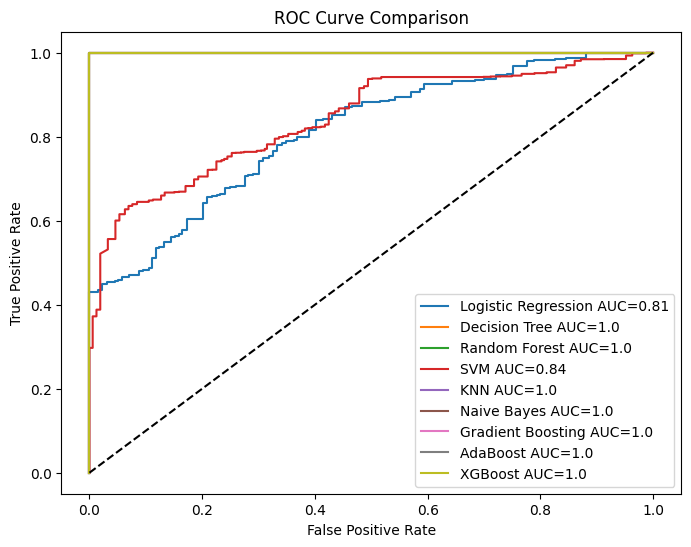

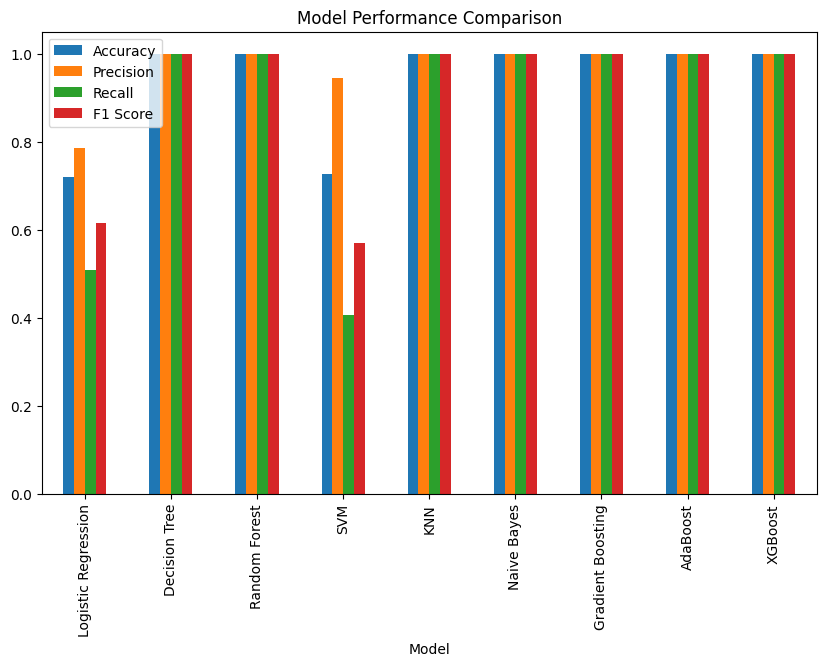

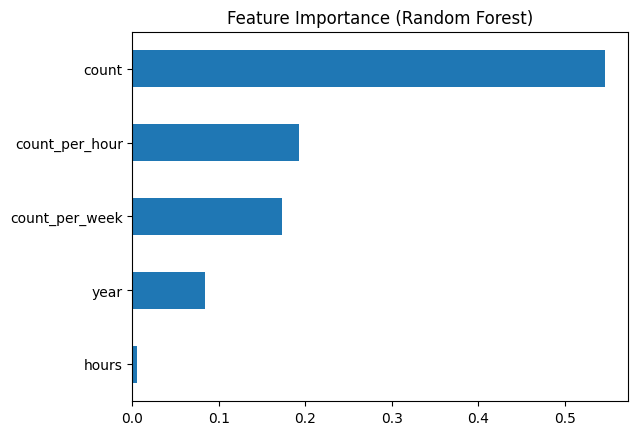

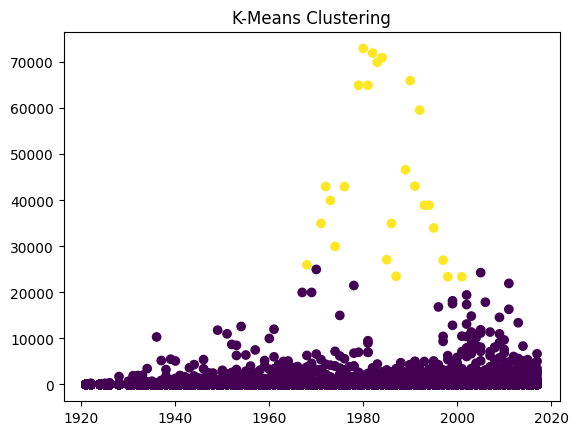

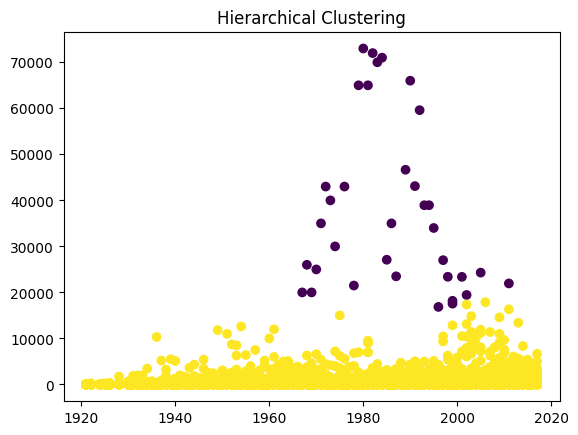

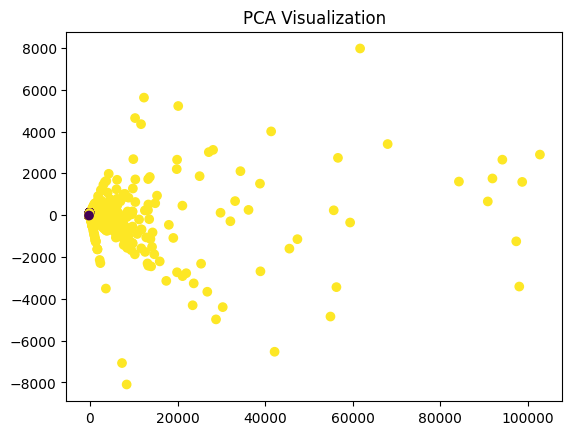

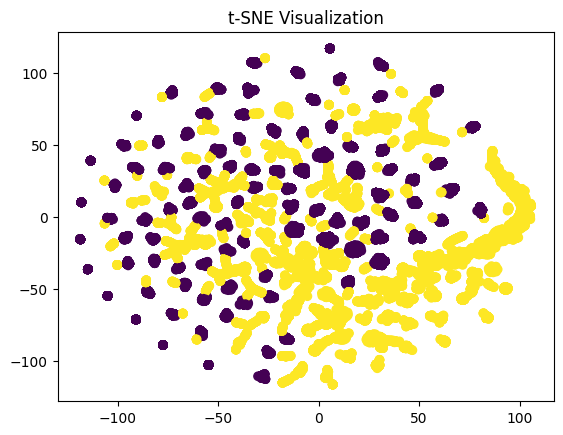

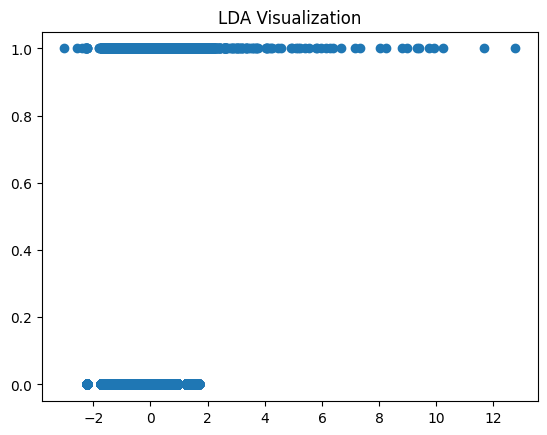

<function matplotlib.pyplot.show(close=None, block=None)>

In [1]:
# =====================================================
# 1 Import Libraries
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
# Supervised Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
# XGBoost
from xgboost import XGBClassifier
# Unsupervised
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
# Dimensionality Reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# =====================================================
# 2 Load Dataset
# =====================================================
df = pd.read_csv("bird_counts2.csv")
print(df.head())
print("Dataset Shape:", df.shape)
 
print(df.isnull().sum())
 
df = df.fillna(df.mean(numeric_only = True))

# =====================================================
# 3 Create Target Variable
# =====================================================
df["bird_present"] = (df["count"] > 0).astype(int)

# =====================================================
# 4 Drop Unnecessary Columns
# =====================================================
df = df.drop(["rownames","species","species_latin","species_binary"], axis=1)

# =====================================================
# 5 Handle Missing Values
# =====================================================
imputer = SimpleImputer(strategy="mean")
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# =====================================================
# 6 Feature / Target Split
# =====================================================
X = df.drop("bird_present", axis=1)
y = df["bird_present"]

# =====================================================
# 7 Train Test Split
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================================================
# 8 Feature Scaling
# =====================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =====================================================
# Store Model Results
# =====================================================
model_names=[]
accuracy_list=[]
precision_list=[]
recall_list=[]
f1_list=[]

# =====================================================
# Model Evaluation Function
# =====================================================
def evaluate_model(model,name):
    y_pred=model.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    prec=precision_score(y_test,y_pred)
    rec=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    model_names.append(name)
    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)
    print("\n======================")
    print(name)
    print("======================")
    print("Accuracy:",acc)
    print("Precision:",prec)
    print("Recall:",rec)
    print("F1 Score:",f1)
    print("\nClassification Report")
    print(classification_report(y_test,y_pred))
    cm=confusion_matrix(y_test,y_pred)
    cm_percent=cm/cm.sum(axis=1).reshape(-1,1)
    cm_percent=(cm_percent*100).astype(int)
    sns.heatmap(cm_percent,annot=True,fmt="d",cmap="Blues")
    plt.title(name+" Confusion Matrix (%)")
    plt.show()

# =====================================================
# 9 Train Models
# =====================================================
models = {
"Logistic Regression": LogisticRegression(),
"Decision Tree": DecisionTreeClassifier(max_depth=4),
"Random Forest": RandomForestClassifier(n_estimators=100),
"SVM": SVC(probability=True),
"KNN": KNeighborsClassifier(),
"Naive Bayes": GaussianNB(),
"Gradient Boosting": GradientBoostingClassifier(),
"AdaBoost": AdaBoostClassifier(),
"XGBoost": XGBClassifier(eval_metric='logloss')
}

for name,model in models.items():
    model.fit(X_train,y_train)
    evaluate_model(model,name)

# =====================================================
# 10 Decision Tree Visualization
# =====================================================
plt.figure(figsize=(18,10))
plot_tree(
models["Decision Tree"],
feature_names=X.columns,
class_names=["No Bird","Bird"],
filled=True
)
plt.title("Decision Tree Visualization")
plt.show()

# =====================================================
# 11 ROC Curve for All Models
# =====================================================
plt.figure(figsize=(8,6))
for name,model in models.items():
    if hasattr(model,"predict_proba"):
        y_prob=model.predict_proba(X_test)[:,1]
    else:
        y_prob=model.decision_function(X_test)
    fpr,tpr,_=roc_curve(y_test,y_prob)
    roc_auc=auc(fpr,tpr)
    plt.plot(fpr,tpr,label=name+" AUC="+str(round(roc_auc,2)))

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# =====================================================
# 12 Model Comparison Bar Chart
# =====================================================
results=pd.DataFrame({
"Model":model_names,
"Accuracy":accuracy_list,
"Precision":precision_list,
"Recall":recall_list,
"F1 Score":f1_list
})
results.set_index("Model").plot(kind="bar",figsize=(10,6))
plt.title("Model Performance Comparison")
plt.show()

# =====================================================
# 13 Feature Importance (Tree Models)
# =====================================================
rf=models["Random Forest"]
importance=rf.feature_importances_
feat_imp=pd.Series(importance,index=X.columns)
feat_imp.sort_values().plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.show()

# =====================================================
# 14 K-Means Clustering
# =====================================================
kmeans=KMeans(n_clusters=2,random_state=42)
clusters=kmeans.fit_predict(X)
plt.scatter(X.iloc[:,0],X.iloc[:,1],c=clusters)
plt.title("K-Means Clustering")
plt.show()

# =====================================================
# 15 Hierarchical Clustering
# =====================================================
hc=AgglomerativeClustering(n_clusters=2)
clusters=hc.fit_predict(X)
plt.scatter(X.iloc[:,0],X.iloc[:,1],c=clusters)
plt.title("Hierarchical Clustering")
plt.show()

# =====================================================
# 16 PCA
# =====================================================
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)
plt.scatter(X_pca[:,0],X_pca[:,1],c=y)
plt.title("PCA Visualization")
plt.show()

# =====================================================
# 17 t-SNE
# =====================================================
tsne=TSNE(n_components=2,random_state=42)
X_tsne=tsne.fit_transform(X)
plt.scatter(X_tsne[:,0],X_tsne[:,1],c=y)
plt.title("t-SNE Visualization")
plt.show()

# =====================================================
# 18 LDA
# =====================================================
lda=LinearDiscriminantAnalysis(n_components=1)
X_lda=lda.fit_transform(X,y)
plt.scatter(X_lda,y)
plt.title("LDA Visualization")
plt.show()
plt.show